In [1]:
import sys
import numpy as np
import matplotlib

print(sys.executable)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)

/opt/anaconda3/envs/portfolio/bin/python
NumPy: 2.4.6
Matplotlib: 3.11.1


In [2]:
import matplotlib.pyplot as plt

print("Matplotlib working")

Matplotlib working


# Smart Portfolio Allocation

## Phase 1 — Data Collection & Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

sns.set_theme(style="whitegrid")

In [2]:
stock_sectors = {
    "Technology": ["AAPL", "MSFT", "NVDA"],
    "Finance": ["JPM", "BAC", "GS"],
    "Energy": ["XOM", "CVX", "COP"],
    "Consumer Staples": ["PG", "KO", "WMT"],
    "Healthcare": ["JNJ", "UNH", "PFE"],
    "Industrial": ["CAT", "BA", "MMM"]
}

stocks = [ticker for tickers in stock_sectors.values() for ticker in tickers]

start_date = "2019-04-01"
end_date = "2025-03-31"

data = yf.download(
    stocks,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

close_data = data["Adj Close"]
close_data.columns = close_data.columns.get_level_values(0)

print(close_data.head())

Ticker           AAPL          BA        BAC         CAT        COP  \
Date                                                                  
2019-04-01  45.530281  382.369507  23.947071  120.426796  52.255741   
2019-04-02  46.192142  381.598022  24.223969  120.375320  51.221275   
2019-04-03  46.508785  375.728760  24.198795  119.576752  50.572834   
2019-04-04  46.589725  386.588318  24.458906  120.323784  50.302628   
2019-04-05  46.901615  382.750366  24.400169  120.521278  51.043732   

Ticker            CVX          GS         JNJ        JPM         KO  \
Date                                                                  
2019-04-01  90.273773  166.214340  113.105865  85.481628  37.499020   
2019-04-02  90.266518  166.856415  112.072342  85.890106  37.378632   
2019-04-03  89.515083  169.695099  111.632858  86.061653  37.065605   
2019-04-04  90.172600  170.852509  110.330757  86.893044  37.306393   
2019-04-05  91.343140  170.979248  110.827164  86.687279  37.298378   

Tick

In [3]:
close_data

Ticker,AAPL,BA,BAC,CAT,COP,CVX,GS,JNJ,JPM,KO,MMM,MSFT,NVDA,PFE,PG,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,,,,
2019-04-01,45.530281,382.369507,23.947071,120.426796,52.255741,90.273773,166.214340,113.105865,85.481628,37.499020,136.490753,111.131226,4.518233,28.299692,85.588707,216.857773,29.340708,58.512856
2019-04-02,46.192142,381.598022,24.223969,120.375320,51.221275,90.266518,166.856415,112.072342,85.890106,37.378632,136.613190,111.289970,4.536079,28.345934,85.679558,215.859833,29.076757,58.262264
2019-04-03,46.508785,375.728760,24.198795,119.576752,50.572834,89.515083,169.695099,111.632858,86.061653,37.065605,137.257172,112.018272,4.675385,28.299692,85.630013,217.122742,29.151739,57.918625
2019-04-04,46.589725,386.588318,24.458906,120.323784,50.302628,90.172600,170.852509,110.330757,86.893044,37.306393,138.480759,111.448700,4.666461,28.233639,85.415268,218.491669,29.427687,58.741913
2019-04-05,46.901615,382.750366,24.400169,120.521278,51.043732,91.343140,170.979248,110.827164,86.687279,37.298378,138.725464,111.943588,4.733138,28.398783,85.596947,219.719315,29.643650,59.056950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-24,219.380630,180.899994,41.904842,335.769226,97.427032,155.126556,565.832336,157.180130,240.753571,66.577690,148.953003,388.519135,121.240097,23.563028,158.834869,499.482269,86.348587,110.483215
2025-03-25,222.382187,182.589996,42.109161,336.702850,97.770256,155.991394,571.528625,154.995087,243.733170,66.442505,149.293427,390.574982,120.521095,23.031193,156.150085,496.513367,83.654198,111.236931
2025-03-26,220.175735,178.550003,41.661606,335.218903,98.389954,157.899689,559.804321,155.668884,243.636093,67.610886,148.495880,385.445190,113.600800,22.724710,159.726639,501.126251,84.098328,112.839806


In [4]:
close_data.columns

Index(['AAPL', 'BA', 'BAC', 'CAT', 'COP', 'CVX', 'GS', 'JNJ', 'JPM', 'KO',
       'MMM', 'MSFT', 'NVDA', 'PFE', 'PG', 'UNH', 'WMT', 'XOM'],
      dtype='str', name='Ticker')

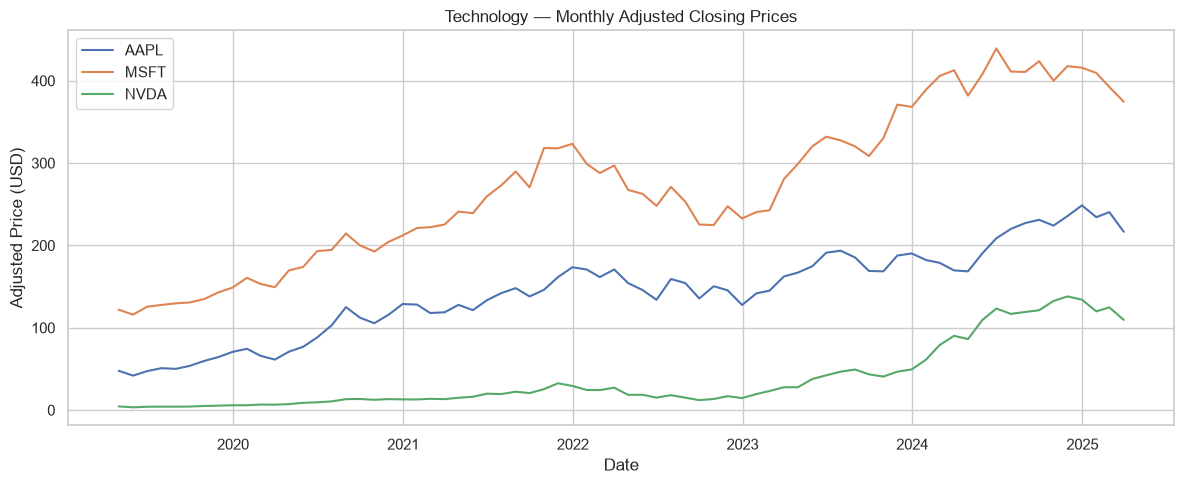

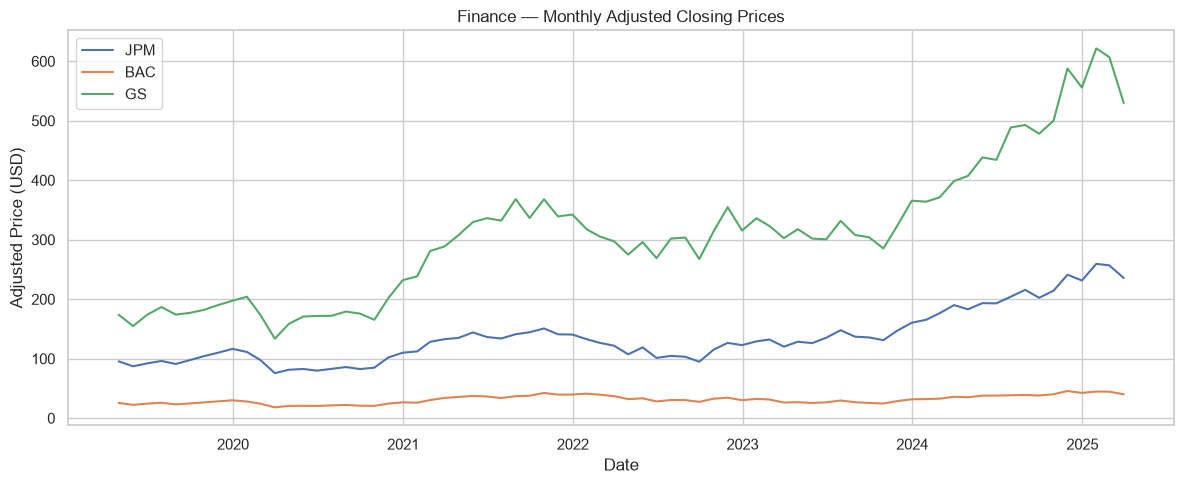

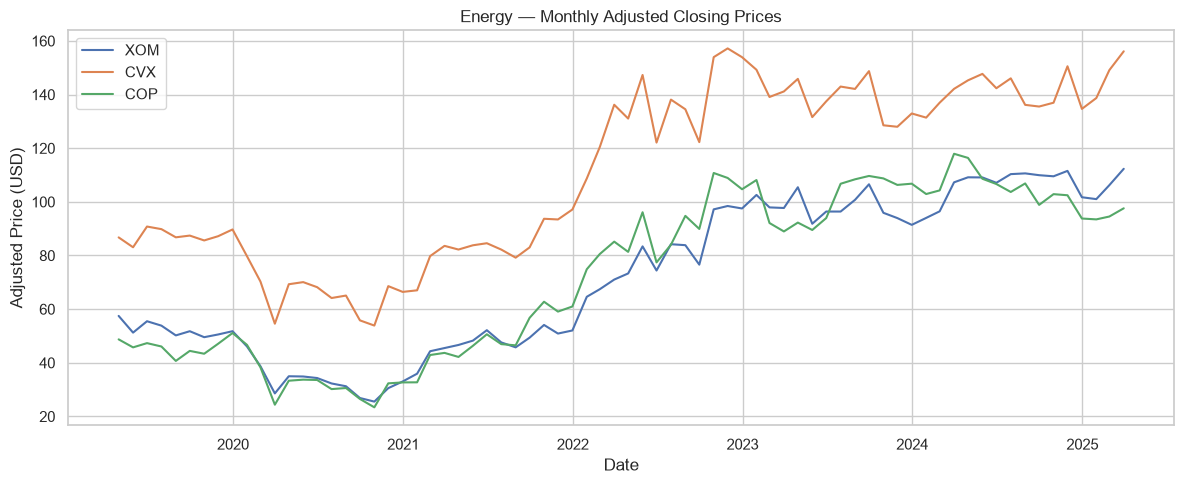

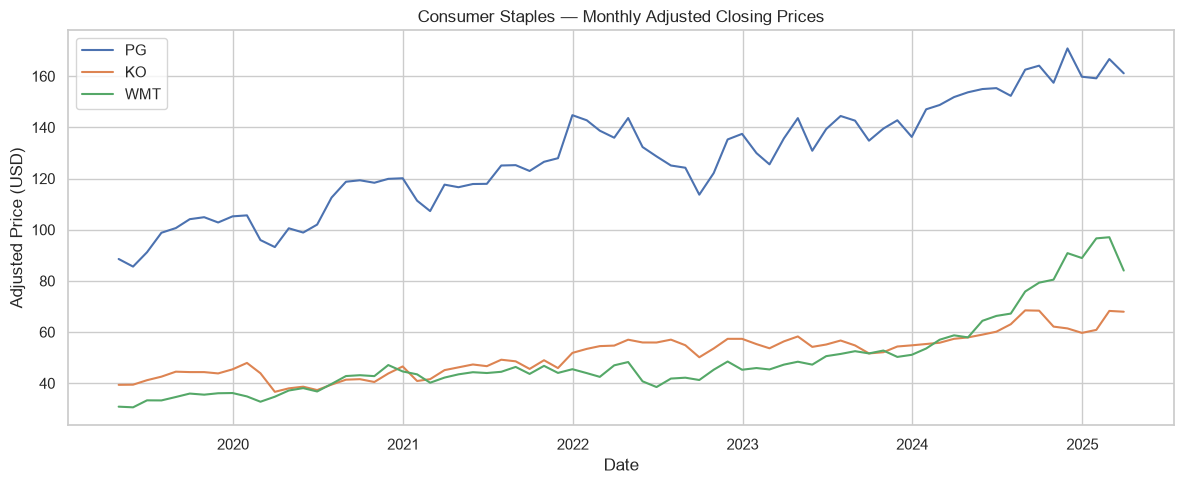

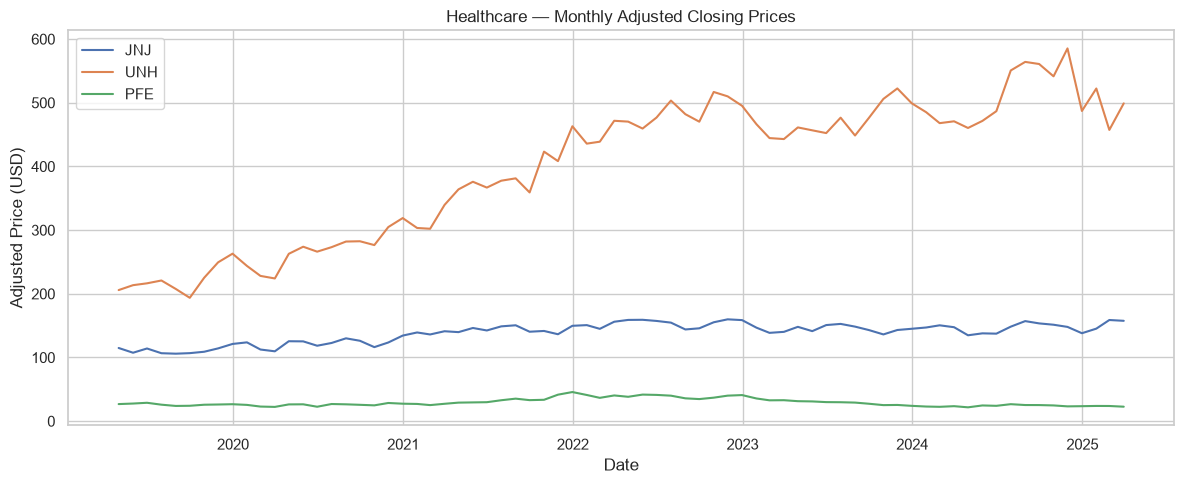

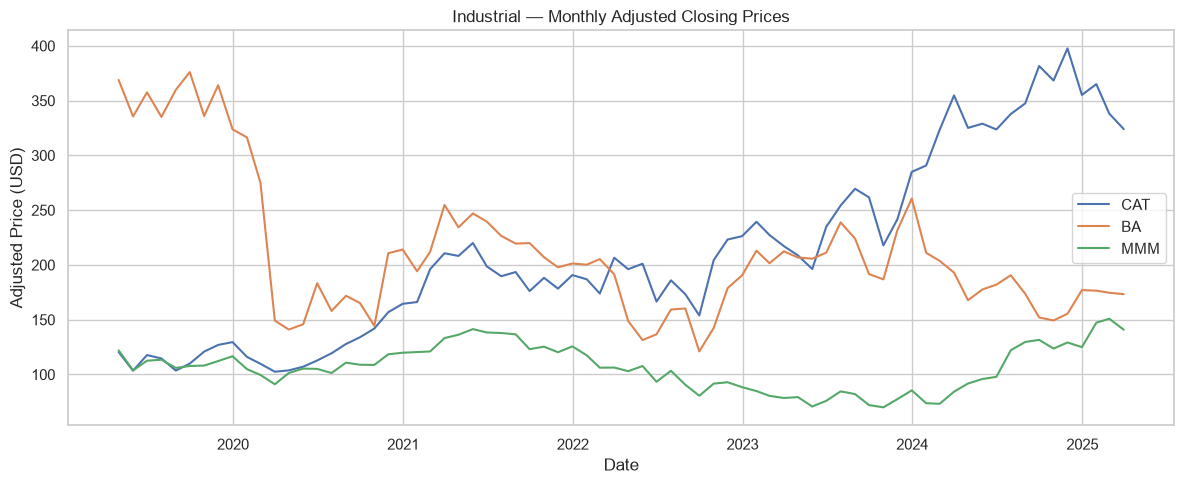

In [5]:
monthly_data = close_data.resample("ME").last()

for sector, tickers in stock_sectors.items():
    plt.figure(figsize=(12, 5))

    for ticker in tickers:
        plt.plot(monthly_data.index, monthly_data[ticker], label=ticker)

    plt.title(f"{sector} — Monthly Adjusted Closing Prices")
    plt.xlabel("Date")
    plt.ylabel("Adjusted Price (USD)")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Phase 2 — Return & Risk Analysis

Convert historical prices into monthly returns and estimate the return and risk characteristics of each asset.

In [6]:
monthly_returns = monthly_data.pct_change(fill_method=None).dropna()

In [7]:
mean_monthly_return = monthly_returns.mean()

print("Mean Monthly Returns:")
print(mean_monthly_return)

Mean Monthly Returns:
Ticker
AAPL    0.024898
BA     -0.001929
BAC     0.010378
CAT     0.018060
COP     0.016759
CVX     0.012284
GS      0.019764
JNJ     0.005696
JPM     0.015831
KO      0.009084
MMM     0.005105
MSFT    0.017766
NVDA    0.055853
PFE     0.000487
PG      0.009698
UNH     0.014702
WMT     0.015790
XOM     0.013721
dtype: float64


In [8]:
std_monthly_return = monthly_returns.std()

print("Monthly Volatility:")
print(std_monthly_return)

Monthly Volatility:
Ticker
AAPL    0.083646
BA      0.130248
BAC     0.089970
CAT     0.091810
COP     0.120079
CVX     0.091112
GS      0.089900
JNJ     0.050326
JPM     0.078211
KO      0.052273
MMM     0.079687
MSFT    0.061776
NVDA    0.142376
PFE     0.076859
PG      0.050314
UNH     0.066755
WMT     0.056422
XOM     0.093471
dtype: float64


In [9]:
return_risk = pd.DataFrame({
    "Ticker": mean_monthly_return.index,
    "Mean Monthly Return": mean_monthly_return.values,
    "Monthly Volatility": std_monthly_return.values
})

return_risk


,Ticker,Mean Monthly Return,Monthly Volatility
0,AAPL,0.024898,0.083646
1,BA,-0.001929,0.130248
2,BAC,0.010378,0.089970
3,CAT,0.018060,0.091810
4,COP,0.016759,0.120079
5,CVX,0.012284,0.091112
6,GS,0.019764,0.089900
7,JNJ,0.005696,0.050326
8,JPM,0.015831,0.078211
9,KO,0.009084,0.052273


In [10]:
tnx = yf.download(
    "^TNX",
    start=start_date,
    end=end_date,
    interval="1mo",
    auto_adjust=False,
    progress=False
)

tnx_yield = tnx["Close"].squeeze().dropna() / 100

annual_rf = tnx_yield.mean()
monthly_rf = (1 + annual_rf) ** (1 / 12) - 1

return_risk["Excess Monthly Return"] = (
    return_risk["Mean Monthly Return"] - monthly_rf
)

return_risk["Sharpe Ratio"] = (
    return_risk["Excess Monthly Return"] /
    return_risk["Monthly Volatility"]
)

print(f"Annualized average risk-free rate: {annual_rf:.4%}")
print(f"Monthly risk-free rate: {monthly_rf:.4%}")

return_risk

Annualized average risk-free rate: 2.6652%
Monthly risk-free rate: 0.2194%


,Ticker,Mean Monthly Return,Monthly Volatility,Excess Monthly Return,Sharpe Ratio
0,AAPL,0.024898,0.083646,0.022704,0.271426
1,BA,-0.001929,0.130248,-0.004124,-0.031661
2,BAC,0.010378,0.089970,0.008183,0.090957
3,CAT,0.018060,0.091810,0.015866,0.172813
4,COP,0.016759,0.120079,0.014565,0.121294
5,CVX,0.012284,0.091112,0.010089,0.110736
6,GS,0.019764,0.089900,0.017569,0.195431
7,JNJ,0.005696,0.050326,0.003501,0.069573
8,JPM,0.015831,0.078211,0.013637,0.174357
9,KO,0.009084,0.052273,0.006890,0.131808


## 3. Constrained Portfolio Optimization

The portfolio is optimized using the Markowitz mean-variance framework. The optimization is long-only and incorporates both individual asset and sector-level concentration limits to improve diversification and control portfolio risk.

In [11]:
import cvxpy as cp

selected_tickers = stocks

mean_returns = mean_monthly_return.loc[selected_tickers].values
cov_matrix = monthly_returns[selected_tickers].cov().values
cov_matrix = (cov_matrix + cov_matrix.T) / 2

lambda_val = 3

w = cp.Variable(len(selected_tickers))

constraints = [
    cp.sum(w) == 1,
    w >= 0,
    w <= 0.10
]

sector_cap = 0.25

for sector, tickers in stock_sectors.items():
    sector_indices = [selected_tickers.index(ticker) for ticker in tickers]
    constraints.append(cp.sum(w[sector_indices]) <= sector_cap)

objective = cp.Maximize(
    mean_returns @ w -
    0.5 * lambda_val * cp.quad_form(
        w,
        cp.psd_wrap(cov_matrix)
    )
)

problem = cp.Problem(objective, constraints)
problem.solve()

if problem.status not in ["optimal", "optimal_inaccurate"]:
    raise ValueError(f"Optimization failed: {problem.status}")

optimal_weights = np.maximum(w.value, 0)
optimal_weights = optimal_weights / optimal_weights.sum()

portfolio_weights = pd.DataFrame({
    "Ticker": selected_tickers,
    "Weight": optimal_weights
})

portfolio_weights["Sector"] = portfolio_weights["Ticker"].map(
    {
        ticker: sector
        for sector, tickers in stock_sectors.items()
        for ticker in tickers
    }
)

portfolio_weights = portfolio_weights.sort_values(
    "Weight",
    ascending=False
).reset_index(drop=True)

portfolio_weights

,Ticker,Weight,Sector
0,NVDA,1.000000e-01,Technology
1,AAPL,1.000000e-01,Technology
2,COP,1.000000e-01,Energy
3,CAT,1.000000e-01,Industrial
4,UNH,1.000000e-01,Healthcare
5,WMT,1.000000e-01,Consumer Staples
6,PG,1.000000e-01,Consumer Staples
7,GS,1.000000e-01,Finance
8,JPM,1.000000e-01,Finance
9,MSFT,5.000000e-02,Technology


### Efficient Frontier

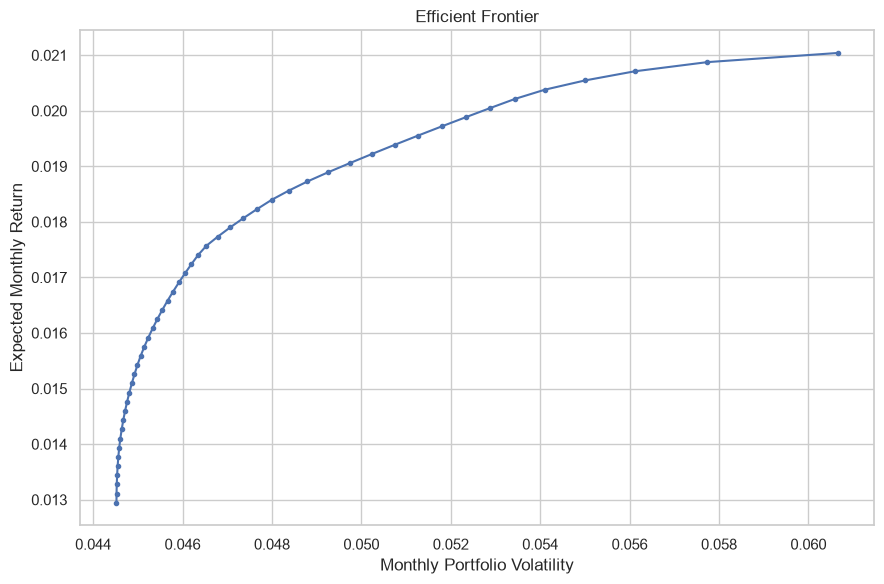

In [12]:
import cvxpy as cp

selected_tickers = stocks
mean_returns = mean_monthly_return.loc[selected_tickers].values
cov_matrix = monthly_returns[selected_tickers].cov().values
cov_matrix = (cov_matrix + cov_matrix.T) / 2

n_assets = len(selected_tickers)
individual_cap = 0.10
sector_cap = 0.25

w = cp.Variable(n_assets)

base_constraints = [
    cp.sum(w) == 1,
    w >= 0,
    w <= individual_cap
]

for sector, tickers in stock_sectors.items():
    sector_indices = [
        selected_tickers.index(ticker)
        for ticker in tickers
    ]
    base_constraints.append(
        cp.sum(w[sector_indices]) <= sector_cap
    )

min_variance_problem = cp.Problem(
    cp.Minimize(cp.quad_form(w, cp.psd_wrap(cov_matrix))),
    base_constraints
)
min_variance_problem.solve()

if min_variance_problem.status not in ["optimal", "optimal_inaccurate"]:
    raise ValueError(
        f"Minimum-variance optimization failed: {min_variance_problem.status}"
    )

min_variance_weights = w.value
min_return = mean_returns @ min_variance_weights

max_return_problem = cp.Problem(
    cp.Maximize(mean_returns @ w),
    base_constraints
)
max_return_problem.solve()

if max_return_problem.status not in ["optimal", "optimal_inaccurate"]:
    raise ValueError(
        f"Maximum-return optimization failed: {max_return_problem.status}"
    )

max_return = mean_returns @ w.value

target_returns = np.linspace(min_return, max_return, 50)

frontier_returns = []
frontier_risks = []

for target in target_returns:
    w_target = cp.Variable(n_assets)

    constraints = [
        cp.sum(w_target) == 1,
        w_target >= 0,
        w_target <= individual_cap,
        mean_returns @ w_target >= target
    ]

    for sector, tickers in stock_sectors.items():
        sector_indices = [
            selected_tickers.index(ticker)
            for ticker in tickers
        ]
        constraints.append(
            cp.sum(w_target[sector_indices]) <= sector_cap
        )

    problem = cp.Problem(
        cp.Minimize(
            cp.quad_form(
                w_target,
                cp.psd_wrap(cov_matrix)
            )
        ),
        constraints
    )

    problem.solve()

    if problem.status in ["optimal", "optimal_inaccurate"]:
        weights = w_target.value
        portfolio_return = mean_returns @ weights
        portfolio_risk = np.sqrt(
            weights.T @ cov_matrix @ weights
        )

        frontier_returns.append(portfolio_return)
        frontier_risks.append(portfolio_risk)

plt.figure(figsize=(9, 6))
plt.plot(
    frontier_risks,
    frontier_returns,
    marker="o",
    markersize=3
)

plt.xlabel("Monthly Portfolio Volatility")
plt.ylabel("Expected Monthly Return")
plt.title("Efficient Frontier")
plt.grid(True)
plt.tight_layout()
plt.show()

## Phase 4 — Machine Learning Return Forecasting

A Random Forest model is used to forecast next-month asset returns from information available up to each prediction date. The forecasts are designed to provide an expected-return signal for the portfolio optimizer while preserving a strictly time-ordered training process.

In [13]:
from sklearn.ensemble import RandomForestRegressor

market_returns = monthly_returns.mean(axis=1)

ml_data = []

for ticker in stocks:
    returns = monthly_returns[ticker]

    features = pd.DataFrame(index=returns.index)
    features["Ticker"] = ticker
    features["Lag_1M"] = returns.shift(1)
    features["Momentum_3M"] = returns.rolling(3).mean().shift(1)
    features["Momentum_6M"] = returns.rolling(6).mean().shift(1)
    features["Volatility_3M"] = returns.rolling(3).std().shift(1)
    features["Volatility_6M"] = returns.rolling(6).std().shift(1)
    features["Market_Return_1M"] = market_returns.shift(1)
    features["Target_Return_1M"] = returns

    ml_data.append(features)

ml_dataset = pd.concat(ml_data).dropna()

print(f"ML dataset shape: {ml_dataset.shape}")
print(ml_dataset.head())

ML dataset shape: (1170, 8)
           Ticker    Lag_1M  Momentum_3M  Momentum_6M  Volatility_3M  \
Date                                                                   
2019-11-30   AAPL  0.110684     0.055728     0.041648       0.065301   
2019-12-31   AAPL  0.077554     0.087067     0.075275       0.020582   
2020-01-31   AAPL  0.098784     0.095674     0.069986       0.016783   
2020-02-29   AAPL  0.054010     0.076783     0.066255       0.022397   
2020-03-31   AAPL -0.114702     0.012697     0.049882       0.112579   

            Volatility_6M  Market_Return_1M  Target_Return_1M  
Date                                                           
2019-11-30       0.095644          0.034650          0.077554  
2019-12-31       0.050464          0.046111          0.098784  
2020-01-31       0.044869          0.037087          0.054010  
2020-02-29       0.045159         -0.030284         -0.114702  
2020-03-31       0.083056         -0.089372         -0.069761  


In [14]:
feature_columns = [
    "Lag_1M",
    "Momentum_3M",
    "Momentum_6M",
    "Volatility_3M",
    "Volatility_6M",
    "Market_Return_1M"
]

X = ml_dataset[feature_columns]
y = ml_dataset["Target_Return_1M"]

train_mask = ml_dataset.index <= "2022-12-31"
test_mask = ml_dataset.index > "2022-12-31"

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

print(f"Training observations: {len(X_train)}")
print(f"Testing observations: {len(X_test)}")
print(f"Training period: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Testing period: {X_test.index.min().date()} to {X_test.index.max().date()}")

Training observations: 684
Testing observations: 486
Training period: 2019-11-30 to 2022-12-31
Testing period: 2023-01-31 to 2025-03-31


In [15]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=8,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Random Forest training completed.")
print(f"Predictions generated: {len(y_pred)}")

Random Forest training completed.
Predictions generated: 486


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_mae = mean_absolute_error(y_test, y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rf_r2 = r2_score(y_test, y_pred)

baseline_pred = np.zeros_like(y_test)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

directional_accuracy = (
    np.sign(y_pred) == np.sign(y_test)
).mean()

print(f"Random Forest MAE: {rf_mae:.4f}")
print(f"Random Forest RMSE: {rf_rmse:.4f}")
print(f"Random Forest R²: {rf_r2:.4f}")
print(f"Random Forest Directional Accuracy: {directional_accuracy:.2%}")

print(f"\nZero-Return Baseline MAE: {baseline_mae:.4f}")
print(f"Zero-Return Baseline RMSE: {baseline_rmse:.4f}")
print(f"Zero-Return Baseline R²: {baseline_r2:.4f}")

Random Forest MAE: 0.0552
Random Forest RMSE: 0.0741
Random Forest R²: -0.0054
Random Forest Directional Accuracy: 53.09%

Zero-Return Baseline MAE: 0.0562
Zero-Return Baseline RMSE: 0.0753
Zero-Return Baseline R²: -0.0375


In [17]:
test_results = ml_dataset.loc[test_mask, ["Ticker", "Target_Return_1M"]].copy()

test_results["Predicted_Return_1M"] = y_pred

test_results["Actual_Direction"] = np.sign(
    test_results["Target_Return_1M"]
)

test_results["Predicted_Direction"] = np.sign(
    test_results["Predicted_Return_1M"]
)

correlation = test_results["Target_Return_1M"].corr(
    test_results["Predicted_Return_1M"]
)

directional_accuracy = (
    test_results["Actual_Direction"]
    == test_results["Predicted_Direction"]
).mean()

print(test_results.head())

print(f"\nPrediction-Return Correlation: {correlation:.4f}")
print(f"Directional Accuracy: {directional_accuracy:.2%}")

           Ticker  Target_Return_1M  Predicted_Return_1M  Actual_Direction  \
Date                                                                         
2023-01-31   AAPL          0.110521             0.016627               1.0   
2023-02-28   AAPL          0.023183            -0.001233               1.0   
2023-03-31   AAPL          0.118649            -0.008827               1.0   
2023-04-30   AAPL          0.028987             0.024788               1.0   
2023-05-31   AAPL          0.046058             0.009045               1.0   

            Predicted_Direction  
Date                             
2023-01-31                  1.0  
2023-02-28                 -1.0  
2023-03-31                 -1.0  
2023-04-30                  1.0  
2023-05-31                  1.0  

Prediction-Return Correlation: 0.0630
Directional Accuracy: 53.09%


In [18]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

print("Random Forest Feature Importance:")
print(feature_importance)

Random Forest Feature Importance:
Market_Return_1M    0.415262
Momentum_3M         0.161873
Lag_1M              0.135961
Momentum_6M         0.118043
Volatility_6M       0.095163
Volatility_3M       0.073698
dtype: float64


In [19]:
ticker_metrics = (
    test_results
    .groupby("Ticker")
    .apply(
        lambda group: pd.Series({
            "MAE": np.mean(
                np.abs(
                    group["Target_Return_1M"]
                    - group["Predicted_Return_1M"]
                )
            ),
            "RMSE": np.sqrt(
                np.mean(
                    (
                        group["Target_Return_1M"]
                        - group["Predicted_Return_1M"]
                    ) ** 2
                )
            ),
            "Correlation": group["Target_Return_1M"].corr(
                group["Predicted_Return_1M"]
            ),
            "Directional Accuracy": np.mean(
                group["Actual_Direction"]
                == group["Predicted_Direction"]
            )
        })
    )
    .sort_values("Correlation", ascending=False)
)

ticker_metrics

,MAE,RMSE,Correlation,Directional Accuracy
Ticker,,,,
BAC,0.058188,0.074063,0.204609,0.555556
WMT,0.039496,0.054293,0.190753,0.740741
NVDA,0.116090,0.146737,0.135890,0.666667
MMM,0.069319,0.091592,0.061165,0.629630
JPM,0.056872,0.065051,0.041216,0.555556
MSFT,0.045132,0.056685,-0.002223,0.518519
GS,0.061244,0.076051,-0.011553,0.518519
PFE,0.048704,0.061995,-0.021639,0.370370
BA,0.074020,0.097645,-0.025383,0.444444


In [20]:
sector_returns = pd.DataFrame(index=monthly_returns.index)

for sector, tickers in stock_sectors.items():
    sector_returns[sector] = monthly_returns[tickers].mean(axis=1)

ml_data_enhanced = []

for ticker in stocks:
    sector = next(
        sector
        for sector, tickers in stock_sectors.items()
        if ticker in tickers
    )

    returns = monthly_returns[ticker]

    features = pd.DataFrame(index=returns.index)
    features["Ticker"] = ticker
    features["Lag_1M"] = returns.shift(1)
    features["Momentum_3M"] = returns.rolling(3).mean().shift(1)
    features["Momentum_6M"] = returns.rolling(6).mean().shift(1)
    features["Momentum_12M"] = returns.rolling(12).mean().shift(1)
    features["Volatility_3M"] = returns.rolling(3).std().shift(1)
    features["Volatility_6M"] = returns.rolling(6).std().shift(1)
    features["Market_Return_1M"] = market_returns.shift(1)
    features["Market_Momentum_3M"] = market_returns.rolling(3).mean().shift(1)
    features["Sector_Return_1M"] = sector_returns[sector].shift(1)
    features["Sector_Momentum_3M"] = (
        sector_returns[sector].rolling(3).mean().shift(1)
    )
    features["Relative_Return_1M"] = (
        returns.shift(1) - sector_returns[sector].shift(1)
    )
    features["Target_Return_1M"] = returns

    ml_data_enhanced.append(features)

ml_dataset_enhanced = pd.concat(ml_data_enhanced).dropna()

print(f"Enhanced ML dataset shape: {ml_dataset_enhanced.shape}")
print(ml_dataset_enhanced.head())

Enhanced ML dataset shape: (1062, 13)
           Ticker    Lag_1M  Momentum_3M  Momentum_6M  Momentum_12M  \
Date                                                                  
2020-05-31   AAPL  0.155374    -0.009696     0.033543      0.037595   
2020-06-30   AAPL  0.085094     0.056902     0.034800      0.055038   
2020-07-31   AAPL  0.147386     0.129285     0.042900      0.056443   
2020-08-31   AAPL  0.165132     0.132537     0.061420      0.063838   
2020-09-30   AAPL  0.216570     0.176362     0.116632      0.083257   

            Volatility_3M  Volatility_6M  Market_Return_1M  \
Date                                                         
2020-05-31       0.144710       0.104022          0.133517   
2020-06-30       0.115185       0.104704          0.034516   
2020-07-31       0.038478       0.112252          0.016017   
2020-08-31       0.042034       0.123095          0.029707   
2020-09-30       0.035933       0.100522          0.066320   

            Market_Momentum_3

In [21]:
enhanced_feature_columns = [
    "Lag_1M",
    "Momentum_3M",
    "Momentum_6M",
    "Momentum_12M",
    "Volatility_3M",
    "Volatility_6M",
    "Market_Return_1M",
    "Market_Momentum_3M",
    "Sector_Return_1M",
    "Sector_Momentum_3M",
    "Relative_Return_1M"
]

X_enhanced = ml_dataset_enhanced[enhanced_feature_columns]
y_enhanced = ml_dataset_enhanced["Target_Return_1M"]

train_mask_enhanced = ml_dataset_enhanced.index <= "2022-12-31"
test_mask_enhanced = ml_dataset_enhanced.index > "2022-12-31"

X_train_enhanced = X_enhanced.loc[train_mask_enhanced]
y_train_enhanced = y_enhanced.loc[train_mask_enhanced]

X_test_enhanced = X_enhanced.loc[test_mask_enhanced]
y_test_enhanced = y_enhanced.loc[test_mask_enhanced]

print(f"Training observations: {len(X_train_enhanced)}")
print(f"Testing observations: {len(X_test_enhanced)}")
print(
    f"Training period: "
    f"{X_train_enhanced.index.min().date()} to "
    f"{X_train_enhanced.index.max().date()}"
)
print(
    f"Testing period: "
    f"{X_test_enhanced.index.min().date()} to "
    f"{X_test_enhanced.index.max().date()}"
)

Training observations: 576
Testing observations: 486
Training period: 2020-05-31 to 2022-12-31
Testing period: 2023-01-31 to 2025-03-31


In [22]:
rf_model_enhanced = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=8,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model_enhanced.fit(
    X_train_enhanced,
    y_train_enhanced
)

y_pred_enhanced = rf_model_enhanced.predict(X_test_enhanced)

print("Enhanced Random Forest training completed.")
print(f"Predictions generated: {len(y_pred_enhanced)}")

Enhanced Random Forest training completed.
Predictions generated: 486


In [23]:
enhanced_mae = mean_absolute_error(y_test_enhanced, y_pred_enhanced)
enhanced_rmse = np.sqrt(
    mean_squared_error(y_test_enhanced, y_pred_enhanced)
)
enhanced_r2 = r2_score(y_test_enhanced, y_pred_enhanced)

enhanced_directional_accuracy = (
    np.sign(y_pred_enhanced) == np.sign(y_test_enhanced)
).mean()

model_comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²",
        "Directional Accuracy"
    ],
    "Original Random Forest": [
        rf_mae,
        rf_rmse,
        rf_r2,
        directional_accuracy
    ],
    "Enhanced Random Forest": [
        enhanced_mae,
        enhanced_rmse,
        enhanced_r2,
        enhanced_directional_accuracy
    ]
})

model_comparison

,Metric,Original Random Forest,Enhanced Random Forest
0,MAE,0.055226,0.055486
1,RMSE,0.074135,0.073496
2,R²,-0.005404,0.011868
3,Directional Accuracy,0.530864,0.543210


In [24]:
ml_predictions = ml_dataset_enhanced.loc[
    test_mask_enhanced,
    ["Ticker", "Target_Return_1M"]
].copy()

ml_predictions["Predicted_Return_1M"] = y_pred_enhanced

ml_predictions

,Ticker,Target_Return_1M,Predicted_Return_1M
Date,,,
2023-01-31,AAPL,0.110521,0.040461
2023-02-28,AAPL,0.023183,0.005733
2023-03-31,AAPL,0.118649,0.005362
2023-04-30,AAPL,0.028987,0.048856
2023-05-31,AAPL,0.046058,0.000713
...,...,...,...
2024-11-30,MMM,0.044914,0.020878
2024-12-31,MMM,-0.033251,0.009738
2025-01-31,MMM,0.179022,0.026746
